# This is the Codeveda Level 1, Task 1: Data Collection and Web Scraping

## Objective
For this task I will scrape book data from **books.toscrape.com** a practice website designed for web scraping. I have chosen this site to avoid legal actions from other international big sites like Linkedin, YouTube, etc.  
What I will extract:
- Book title  
- Price (£)  
- Rating (One to Five)  
- Availability (In stock / Out of stock)  

The site has 50 pages, 20 books per page (1000 books total).  
We will handle:
- Pagination  
- Concurrent requests (polite)  
- Retries on failure  
- User‑agent rotation to avoid blocking  
- Saving data to CSV (and optionally SQLite)

---






## 1. Install and Import Required Libraries

In [6]:
# This cell installs our required libraries
!pip install requests beautifulsoup4 lxml pandas fake-useragent tenacity matplotlib seaborn

In [7]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
from fake_useragent import UserAgent
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully.")

All libraries imported successfully.


- Now we can define constants that control the scraping behaviour.

In [8]:
# Our target website

BASE_URL = "http://books.toscrape.com/catalogue/page-{}.html"

# How many pages to scrape (max 50)

MAX_PAGES = 50

# Concurrency (number of parallel requests)

CONCURRENCY = 5

# Polite delay between page completions (seconds)

REQUEST_DELAY = 0.5
REQUEST_JITTER = 0.3   # random additional delay

# Timeout for each HTTP request

TIMEOUT = 10

# Number of retries on failure

RETRY_ATTEMPTS = 3

# User‑agent rotation
ua = UserAgent()

print(f"Configuration loaded. Pages: {MAX_PAGES}, Concurrency: {CONCURRENCY}")

Configuration loaded. Pages: 50, Concurrency: 5


- Then we use tenacity to automatically retry failed requests (network errors, timeouts) by using a random user‑agent for each request.

In [9]:
@retry(
    stop=stop_after_attempt(RETRY_ATTEMPTS),
    wait=wait_exponential(multiplier=1, min=2, max=10),
    retry=retry_if_exception_type((requests.RequestException, ConnectionError))
)
def fetch_page(url):
    """Fetch HTML content of a single page with retry logic."""
    headers = {"User-Agent": ua.random}
    resp = requests.get(url, headers=headers, timeout=TIMEOUT)
    resp.raise_for_status()   # Raise an error for bad status codes
    return resp.text

- We parse a single book card using a BeautifulSoup element representing one book card, then extract the fields.

In [10]:
def parse_book_card(card_soup):
    """Extract title, price, rating, availability from a book card."""
    try:
        # Title is inside <h3><a title="..."></a></h3>
        title_elem = card_soup.select_one("h3 a")
        title = title_elem["title"] if title_elem else "Unknown Title"

        # Price inside <p class="price_color">£XX.XX</p>
        price_elem = card_soup.select_one(".price_color")
        if price_elem:
            price_text = price_elem.text.replace("£", "").replace("Â", "")
            price = float(price_text)
        else:
            price = 0.0

        # Rating: second class of <p class="star-rating Four">
        rating_elem = card_soup.select_one("p[class*=star-rating]")
        rating = rating_elem["class"][1] if rating_elem else "Zero"

        # Availability inside <p class="instock">In stock</p>
        avail_elem = card_soup.select_one(".instock")
        availability = avail_elem.text.strip() if avail_elem else "Out of stock"

        return {
            "title": title,
            "price": price,
            "rating": rating,
            "availability": availability
        }
    except Exception as e:
        # If parsing fails for a card, return None (will be skipped)
        print(f"Error parsing card: {e}")
        return None

- Then we parse a full page of listings since given HTML of a catalogue page, we can extract all book cards and parse them.

In [11]:
def parse_listing(html):
    """Parse a page and return a list of book dictionaries."""
    soup = BeautifulSoup(html, "lxml")
    book_cards = soup.select(".product_pod")
    books = []
    for card in book_cards:
        book = parse_book_card(card)
        if book:
            books.append(book)
    return books

- We use ThreadPoolExecutor to fetch multiple pages concurrently, but we add a random delay after each page completion to be respectful to the server.

In [12]:
def scrape_all_pages():
    """Scrape all pages and return a list of all books."""
    urls = [BASE_URL.format(i) for i in range(1, MAX_PAGES + 1)]
    all_books = []

    print(f"Starting scrape of {len(urls)} pages with concurrency {CONCURRENCY}...")

    with ThreadPoolExecutor(max_workers=CONCURRENCY) as executor:
        # Submit all fetch tasks
        future_to_url = {executor.submit(fetch_page, url): url for url in urls}

        for future in as_completed(future_to_url):
            url = future_to_url[future]
            try:
                html = future.result()
                books = parse_listing(html)
                all_books.extend(books)
                print(f"✓ Scraped {len(books)} books from {url}")
            except Exception as e:
                print(f"✗ Failed to scrape {url}: {e}")

            # Polite delay between page completions
            sleep_time = REQUEST_DELAY + random.uniform(0, REQUEST_JITTER)
            time.sleep(sleep_time)

    print(f"\n✅ Total books scraped: {len(all_books)}")
    return all_books

- Now execute the scraping. This may take 30‑60 seconds.

In [13]:
books = scrape_all_pages()

Starting scrape of 50 pages with concurrency 5...
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-1.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-3.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-4.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-5.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-2.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-7.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-8.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-10.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-6.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-9.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-13.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-11.html
✓ Scraped 20 books from http://books.toscrape.com/catalogue/page-12.html
✓ Scraped 

- We store the data in a pandas DataFrame, then export to CSV and optionally to an SQLite database.

In [14]:
# Convert to DataFrame
df = pd.DataFrame(books)

# Add an ID column (optional)
df.insert(0, 'id', range(1, len(df)+1))

# Show first few rows
df.head()

# Save to CSV
csv_filename = "scraped_books.csv"
df.to_csv(csv_filename, index=False)
print(f"Saved {len(df)} books to {csv_filename}")

# Optional: Save to SQLite
conn = sqlite3.connect("books.db")
df.to_sql("books", conn, if_exists="replace", index=False)
conn.close()
print("Also saved to books.db (SQLite).")

Saved 1000 books to scraped_books.csv
Also saved to books.db (SQLite).


##  Exploratory Data Analysis (EDA)

- We perform basic analysis to understand the scraped data.

In [15]:
# Display basic info
print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)
print("\nSummary statistics:")
print(df.describe())

Dataset shape: (1000, 5)

Column data types:
id                int64
title            object
price           float64
rating           object
availability     object
dtype: object

Summary statistics:
                id       price
count  1000.000000  1000.00000
mean    500.500000    35.07035
std     288.819436    14.44669
min       1.000000    10.00000
25%     250.750000    22.10750
50%     500.500000    35.98000
75%     750.250000    47.45750
max    1000.000000    59.99000


## Rating distribution


Rating distribution:
rating
One      226
Three    203
Five     196
Two      196
Four     179
Name: count, dtype: int64


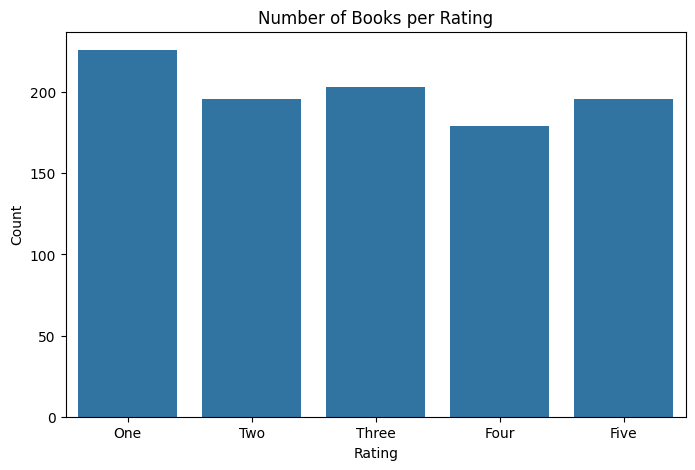

In [16]:
rating_counts = df['rating'].value_counts()
print("\nRating distribution:")
print(rating_counts)

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='rating', order=['One','Two','Three','Four','Five'])
plt.title("Number of Books per Rating")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## Price distribution

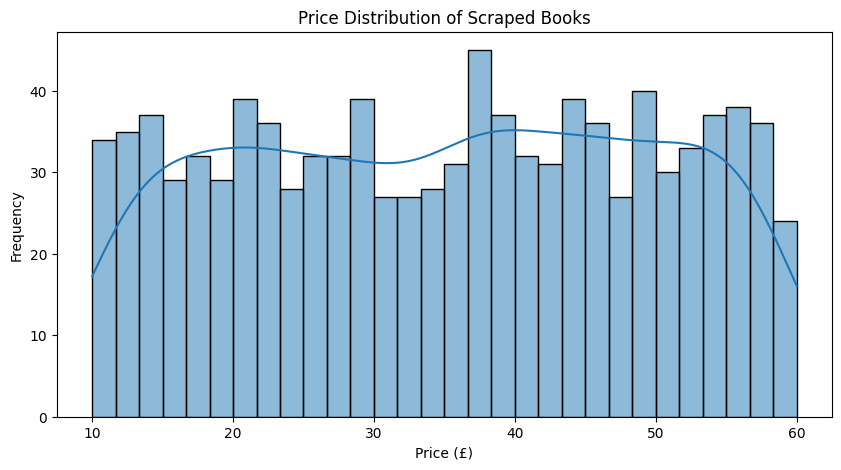

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title("Price Distribution of Scraped Books")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

## Price by rating (boxplot)

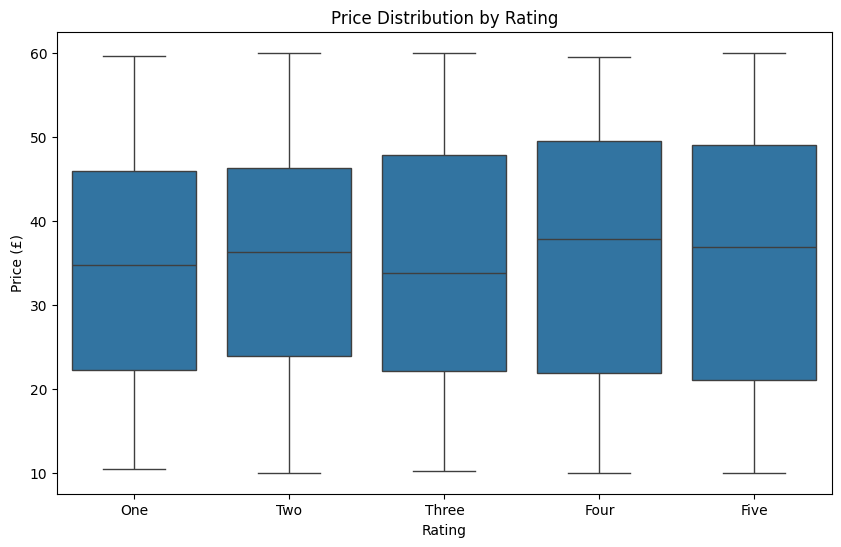

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='rating', y='price', order=['One','Two','Three','Four','Five'])
plt.title("Price Distribution by Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.show()

## Most expensive books

In [19]:
top_expensive = df.nlargest(10, 'price')[['title', 'price', 'rating']]
print("Top 10 most expensive books:")
top_expensive

Top 10 most expensive books:


,title,price,rating
648,The Perfect Play (Play by Play #1),59.99,Three
617,Last One Home (New Beginnings #1),59.98,Three
860,Civilization and Its Discontents,59.95,Two
560,The Barefoot Contessa Cookbook,59.92,Five
366,The Diary of a Young Girl,59.90,Three
657,The Bone Hunters (Lexy Vaughan & Steven Macaul...,59.71,Three
113,Thomas Jefferson and the Tripoli Pirates: The ...,59.64,One
387,Boar Island (Anna Pigeon #19),59.48,Three
393,The Improbability of Love,59.45,One
549,The Man Who Mistook His Wife for a Hat and Oth...,59.45,Four


## Cheapest books

In [20]:
cheapest = df.nsmallest(10, 'price')[['title', 'price', 'rating']]
print("Top 10 cheapest books:")
cheapest

Top 10 cheapest books:


,title,price,rating
638,An Abundance of Katherines,10.00,Five
521,The Origin of Species,10.01,Four
716,The Tipping Point: How Little Things Can Make ...,10.02,Two
64,Patience,10.16,Three
302,Greek Mythic History,10.23,Five
558,The Fellowship of the Ring (The Lord of the Ri...,10.27,Two
479,History of Beauty,10.29,Four
202,The Lucifer Effect: Understanding How Good Peo...,10.40,One
434,"NaNo What Now? Finding your editing process, r...",10.41,Four
274,Pet Sematary,10.56,Three


## Summary Report


In [21]:
print("="*50)
print("📊 WEB SCRAPING SUMMARY REPORT")
print("="*50)
print(f"Target website: books.toscrape.com")
print(f"Pages scraped: {MAX_PAGES}")
print(f"Total books extracted: {len(df)}")
print(f"Price range: £{df['price'].min():.2f} – £{df['price'].max():.2f}")
print(f"Average price: £{df['price'].mean():.2f}")
print(f"Most common rating: {df['rating'].mode()[0]}")
print(f"Books in stock: {df[df['availability']=='In stock'].shape[0]}")
print(f"Books out of stock: {df[df['availability']!='In stock'].shape[0]}")
print("="*50)

📊 WEB SCRAPING SUMMARY REPORT
Target website: books.toscrape.com
Pages scraped: 50
Total books extracted: 1000
Price range: £10.00 – £59.99
Average price: £35.07
Most common rating: One
Books in stock: 1000
Books out of stock: 0


In [22]:
import os
print("Files in current directory:")
for f in os.listdir():
    if f.endswith('.csv') or f.endswith('.db'):
        print(f"  {f}")

Files in current directory:
  scraped_books.csv
  books.db
